# Raw .bin → CIR Exploration

Reads binary measurement frames, parses IQ / GPS fields, and applies the LFM matched-filter sliding correlation to produce the raw (uncalibrated) CIR.

**Reference:** `src/io/bin_read.py`

## 1  Imports & project root

In [1]:
import sys, math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import contextily as ctx
from pyproj import Transformer

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io.bin_read import (
    read_bin_to_cir,
    _load_frames,
    _parse_iq,
    _parse_gps,
    _sliding_correlate,
    _DEVICE,
    FRAME_LEN, U, FS_HZ, BW_HZ,
)
from src.paths import RAW_MEA_DIR, RAW_CALI_DIR

matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

print(f"Project root : {PROJECT_ROOT}")
print(f"FRAME_LEN={FRAME_LEN}, U={U}, FS_HZ={FS_HZ/1e6:.0f} MHz, BW={BW_HZ/1e6:.0f} MHz")
print(f"Compute device: {_DEVICE}" + (" ✓ GPU" if _DEVICE.type == "cuda" else " (CPU fallback)"))


Project root : /home/guo/桌面/project/chan_meas
FRAME_LEN=4132, U=1024, FS_HZ=100 MHz, BW=50 MHz
Compute device: cuda ✓ GPU


## 2  Select data file

In [2]:
# ── Pick one file to explore ─────────────────────────────────────────────────
# Change this path to the actual .bin you want to inspect
BIN_PATH = RAW_MEA_DIR  # or RAW_CALI_DIR, or a specific Path("...").bin

MAX_FRAMES = None  # limit for fast iteration; set None for all frames

print(f"Data path  : {BIN_PATH}")
print(f"Max frames : {MAX_FRAMES}")

Data path  : /home/guo/桌面/win_data/data_mea/data_save/Mea_data
Max frames : None


## 3  Load raw frames

In [3]:
BIN_PATH = RAW_MEA_DIR / "20260123_nuaaeast_1400mHz_LOS_Move30kmh_001"
frames = _load_frames(BIN_PATH, max_frames=MAX_FRAMES)
n_frames = frames.shape[0]

print(f"frames.shape = {frames.shape}  (n_frames × FRAME_LEN)")
print(f"Total bytes loaded: {frames.nbytes / 1e6:.2f} MB")

frames.shape = (74917, 4132)  (n_frames × FRAME_LEN)
Total bytes loaded: 309.56 MB


## 4  Parse GPS fields

In [4]:
gps = _parse_gps(frames)

for key, val in gps.items():
    print(f"  {key:8s}: min={val.min():.6g}  max={val.max():.6g}  (first 5: {val[:5]})")

  lat     : min=31.9375  max=31.943  (first 5: [31.93937667 31.93937667 31.93937667 31.93937667 31.93937667])
  lon     : min=118.789  max=118.793  (first 5: [118.79040183 118.79040183 118.79040183 118.79040183 118.79040183])
  alt     : min=9.6  max=17.3  (first 5: [14.6 14.6 14.6 14.6 14.6])
  hour    : min=2  max=2  (first 5: [2 2 2 2 2])
  minute  : min=12  max=19  (first 5: [12 12 12 12 12])
  second  : min=0  max=59  (first 5: [50 50 50 50 50])


Text(0.5, 1.0, 'GPS Trajectory')

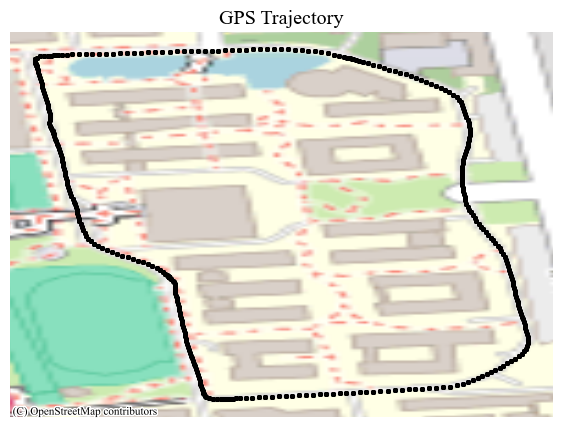

In [5]:
import contextily as ctx
from pyproj import Transformer

fig, ax0 = plt.subplots(1, 1, figsize=(7, 5))

_tr = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
_x, _y = _tr.transform(gps['lon'], gps['lat'])

# 每 20 帧取一点，视觉无损
step = 20
ax0.scatter(_x[::step], _y[::step], s=6, color='k', zorder=5)

# zoom 固定，tiles 首次下载后本地缓存
ctx.add_basemap(ax0, source=ctx.providers.OpenStreetMap.Mapnik, zoom=15)
ax0.set_axis_off()
ax0.set_title('GPS Trajectory')


## 5  Parse IQ and inspect raw signal

iq.shape = (74917, 1024)  (n_frames × U), dtype=complex64


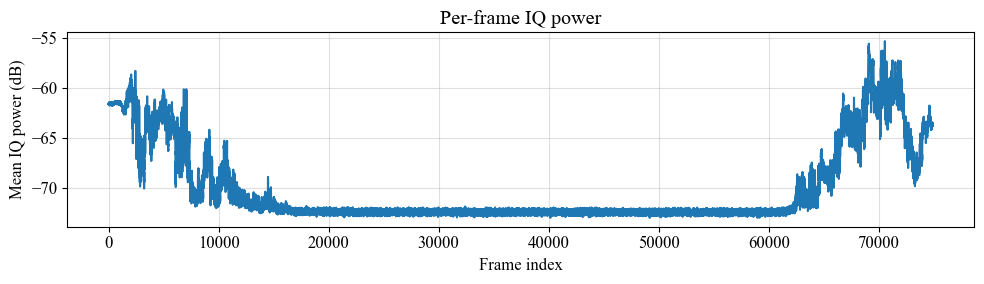

In [6]:
iq = _parse_iq(frames)
print(f"iq.shape = {iq.shape}  (n_frames × U), dtype={iq.dtype}")

# Per-frame power — computed on GPU
_iq_t = torch.from_numpy(iq).to(_DEVICE)
power_per_frame_db = 10 * np.log10(                                                                                                                                     
(np.abs(iq) ** 2).mean(axis=1) + 1e-30                                                                                                                              
) 

plt.figure(figsize=(10, 3))
plt.plot(power_per_frame_db)
plt.xlabel('Frame index')
plt.ylabel('Mean IQ power (dB)')
plt.title('Per-frame IQ power')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


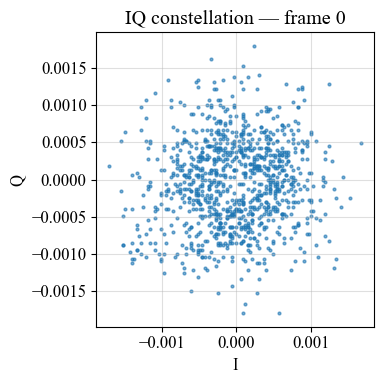

In [7]:
# IQ constellation of one frame
frame_idx = 0
plt.figure(figsize=(4, 4))
plt.scatter(iq[frame_idx].real, iq[frame_idx].imag, s=4, alpha=0.6)
plt.xlabel('I')
plt.ylabel('Q')
plt.title(f'IQ constellation — frame {frame_idx}')
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6  Matched-filter correlation → raw CIR

In [8]:
cir_raw = _sliding_correlate(iq)   # modifies iq in-place (DC removal)
print(f"cir_raw.shape = {cir_raw.shape}  (n_frames × U), dtype={cir_raw.dtype}")

delay_axis_ns = np.arange(U) / BW_HZ * 1e9  # delay bins → nanoseconds

cir_raw.shape = (74917, 1024)  (n_frames × U), dtype=complex64


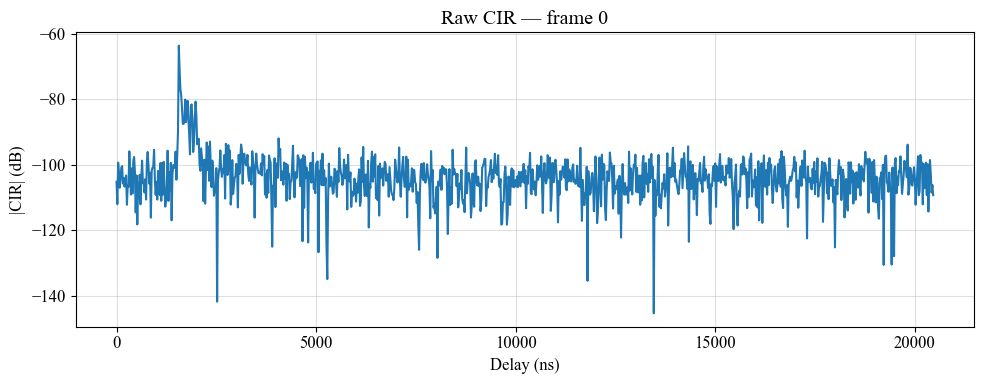

In [9]:
# ── CIR magnitude of a single frame ─────────────────────────────────────────
frame_idx = 0
cir_db = 20 * np.log10(np.abs(cir_raw[frame_idx]) + 1e-10)

plt.figure(figsize=(10, 4))
plt.plot(delay_axis_ns, cir_db)
plt.xlabel('Delay (ns)')
plt.ylabel('|CIR| (dB)')
plt.title(f'Raw CIR — frame {frame_idx}')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

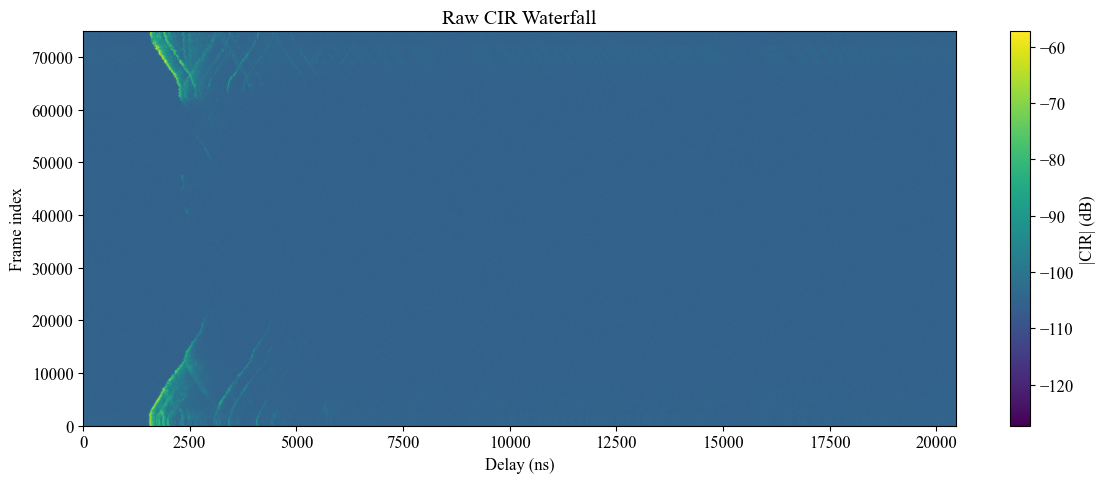

In [10]:
# CIR waterfall (all frames) — GPU
if '_cir_t' not in dir():
    _cir_t = torch.from_numpy(cir_raw).to(_DEVICE)
cir_power_db = (20 * torch.log10(_cir_t.abs() + 1e-10)).cpu().numpy()
vmax = cir_power_db.max()

plt.figure(figsize=(12, 5))
plt.imshow(
    cir_power_db,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    vmin=vmax - 70,
    vmax=vmax,
    extent=[delay_axis_ns[0], delay_axis_ns[-1], 0, n_frames],
)
plt.colorbar(label='|CIR| (dB)')
plt.xlabel('Delay (ns)')
plt.ylabel('Frame index')
plt.title('Raw CIR Waterfall')
plt.tight_layout()
plt.show()
